In [2]:
import pandas as pd

target = "Late_delivery_risk"

base_dir =  "d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/dataset/engineered/"

df_train = pd.read_csv(f"{base_dir}/df_train.csv")
df_valid = pd.read_csv(f"{base_dir}/df_valid.csv")
df_test = pd.read_csv(f"{base_dir}/df_test.csv")

X_train_selected = df_train.drop(columns=[target])
y_train = df_train[target]

X_valid_selected = df_valid.drop(columns=[target])
y_valid = df_valid[target]

X_test_selected = df_test.drop(columns=[target])
y_test = df_test[target]

print(X_train_selected.shape, X_valid_selected.shape, X_test_selected.shape)

(115394, 10) (28827, 10) (35869, 10)


### Model Selection

In [3]:
# import modeling libraries
import os
from pathlib import Path
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.catboost
from mlflow.tracking import MlflowClient

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [4]:
from pathlib import Path
import mlflow
from mlflow.tracking import MlflowClient

if mlflow.active_run() is not None:
    mlflow.end_run()

PROJECT_ROOT = Path(
    r"D:\PENS-EEPIS\SDT A Semester 4 2026\Project TA"
)

MLFLOW_DIR = PROJECT_ROOT / "model" / "artifacts" / "mlflow"
TRACKING_DB = MLFLOW_DIR / "mlflow.db"
ARTIFACT_DIR = MLFLOW_DIR / "artifacts"

MLFLOW_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{TRACKING_DB.as_posix()}")

MLFLOW_EXPERIMENT_SELECTION = "late-shipment-risk-model-selection"
MLFLOW_EXPERIMENT_TUNING = "late-shipment-risk-model-tuning"
REGISTERED_MODEL_NAME = "Late Shipment Risk Model"

client = MlflowClient()

def get_or_create_experiment(name):
    experiment = client.get_experiment_by_name(name)

    if experiment is None:
        return client.create_experiment(
            name=name,
            artifact_location=ARTIFACT_DIR.as_uri()
        )

    return experiment.experiment_id

EXPERIMENT_SELECTION_ID = get_or_create_experiment(MLFLOW_EXPERIMENT_SELECTION)
EXPERIMENT_TUNING_ID = get_or_create_experiment(MLFLOW_EXPERIMENT_TUNING)

mlflow.set_experiment(experiment_id=EXPERIMENT_SELECTION_ID)

results = {}

print("Tracking URI:", mlflow.get_tracking_uri())
print("Selection experiment ID:", EXPERIMENT_SELECTION_ID)
print("Tuning experiment ID:", EXPERIMENT_TUNING_ID)
print("Artifact dir:", ARTIFACT_DIR)


2026/05/12 12:14:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/12 12:14:32 INFO mlflow.store.db.utils: Updating database tables


Tracking URI: sqlite:///D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/mlflow/mlflow.db
Selection experiment ID: 1
Tuning experiment ID: 2
Artifact dir: D:\PENS-EEPIS\SDT A Semester 4 2026\Project TA\model\artifacts\mlflow\artifacts


In [5]:
logit = LogisticRegression(
    max_iter=1000,
    random_state=42
)

with mlflow.start_run(run_name="LogisticRegression"):
    mlflow.set_tag("model_name", "LogisticRegression")
    mlflow.set_tag("stage", "model_selection")
    mlflow.set_tag("target", "Late_delivery_risk")

    mlflow.log_params({
        "max_iter": 1000,
        "random_state": 42,
        "train_rows": X_train_selected.shape[0],
        "valid_rows": X_valid_selected.shape[0],
        "n_features": X_train_selected.shape[1]
    })

    logit.fit(X_train_selected, y_train)

    y_pred_logit = logit.predict(X_valid_selected)
    y_proba_logit = logit.predict_proba(X_valid_selected)[:, 1]

    logit_metrics = {
        "accuracy": accuracy_score(y_valid, y_pred_logit),
        "precision": precision_score(y_valid, y_pred_logit, zero_division=0),
        "recall": recall_score(y_valid, y_pred_logit, zero_division=0),
        "f1": f1_score(y_valid, y_pred_logit, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba_logit)
    }

    mlflow.log_metrics(logit_metrics)

    logit_report = classification_report(y_valid, y_pred_logit, zero_division=0)
    logit_cm = confusion_matrix(y_valid, y_pred_logit)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/logit_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(logit_report)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/logit_confusion_matrix.txt", "w", encoding="utf-8") as f:
        f.write(str(logit_cm))

    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/logit_classification_report.txt")
    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/logit_confusion_matrix.txt")

    mlflow.sklearn.log_model(
        sk_model=logit,
        name="logistic_regression_model"
    )

    results["LogisticRegression"] = logit_metrics

print("Logistic Regression Evaluation")
print("Accuracy :", logit_metrics["accuracy"])
print("Precision:", logit_metrics["precision"])
print("Recall   :", logit_metrics["recall"])
print("F1 Score :", logit_metrics["f1"])
print("ROC AUC  :", logit_metrics["roc_auc"])
print("\nClassification Report:")
print(logit_report)
print("\nConfusion Matrix:")
print(logit_cm)

2026/05/12 12:14:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression Evaluation
Accuracy : 0.6945571859714851
Precision: 0.85
Recall   : 0.5366039170945046
F1 Score : 0.657885534444574
ROC AUC  : 0.7265732283548704

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.89      0.72     13050
           1       0.85      0.54      0.66     15777

    accuracy                           0.69     28827
   macro avg       0.73      0.71      0.69     28827
weighted avg       0.74      0.69      0.69     28827


Confusion Matrix:
[[11556  1494]
 [ 7311  8466]]


In [6]:
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight=None
)

with mlflow.start_run(run_name="DecisionTree"):
    mlflow.set_tag("model_name", "DecisionTree")
    mlflow.set_tag("stage", "model_selection")
    mlflow.set_tag("target", "Late_delivery_risk")

    mlflow.log_params({
        "random_state": 42,
        "class_weight": "None",
        "train_rows": X_train_selected.shape[0],
        "valid_rows": X_valid_selected.shape[0],
        "n_features": X_train_selected.shape[1]
    })

    dt.fit(X_train_selected, y_train)

    y_pred_dt = dt.predict(X_valid_selected)
    y_proba_dt = dt.predict_proba(X_valid_selected)[:, 1]

    dt_metrics = {
        "accuracy": accuracy_score(y_valid, y_pred_dt),
        "precision": precision_score(y_valid, y_pred_dt, zero_division=0),
        "recall": recall_score(y_valid, y_pred_dt, zero_division=0),
        "f1": f1_score(y_valid, y_pred_dt, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba_dt)
    }

    mlflow.log_metrics(dt_metrics)

    dt_report = classification_report(y_valid, y_pred_dt, zero_division=0)
    dt_cm = confusion_matrix(y_valid, y_pred_dt)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/dt_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(dt_report)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/dt_confusion_matrix.txt", "w", encoding="utf-8") as f:
        f.write(str(dt_cm))

    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/dt_classification_report.txt")
    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/dt_confusion_matrix.txt")

    mlflow.sklearn.log_model(
        sk_model=dt,
        name="decision_tree_model"
    )

    results["DecisionTree"] = dt_metrics

print("Decision Tree Evaluation")
print("Accuracy :", dt_metrics["accuracy"])
print("Precision:", dt_metrics["precision"])
print("Recall   :", dt_metrics["recall"])
print("F1 Score :", dt_metrics["f1"])
print("ROC AUC  :", dt_metrics["roc_auc"])
print("\nClassification Report:")
print(dt_report)
print("\nConfusion Matrix:")
print(dt_cm)

2026/05/12 12:14:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Decision Tree Evaluation
Accuracy : 0.6323238630450619
Precision: 0.6657914959016393
Recall   : 0.6589972745135324
F1 Score : 0.6623769630172331
ROC AUC  : 0.6311832103428119

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.60      0.60     13050
           1       0.67      0.66      0.66     15777

    accuracy                           0.63     28827
   macro avg       0.63      0.63      0.63     28827
weighted avg       0.63      0.63      0.63     28827


Confusion Matrix:
[[ 7831  5219]
 [ 5380 10397]]


In [7]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

with mlflow.start_run(run_name="RandomForest"):
    mlflow.set_tag("model_name", "RandomForest")
    mlflow.set_tag("stage", "model_selection")
    mlflow.set_tag("target", "Late_delivery_risk")

    mlflow.log_params({
        "n_estimators": 500,
        "max_depth": 8,
        "min_samples_split": 50,
        "min_samples_leaf": 20,
        "max_features": "sqrt",
        "class_weight": "None",
        "random_state": 42,
        "n_jobs": -1,
        "train_rows": X_train_selected.shape[0],
        "valid_rows": X_valid_selected.shape[0],
        "n_features": X_train_selected.shape[1]
    })

    rf.fit(X_train_selected, y_train)

    y_pred_rf = rf.predict(X_valid_selected)
    y_proba_rf = rf.predict_proba(X_valid_selected)[:, 1]

    rf_metrics = {
        "accuracy": accuracy_score(y_valid, y_pred_rf),
        "precision": precision_score(y_valid, y_pred_rf, zero_division=0),
        "recall": recall_score(y_valid, y_pred_rf, zero_division=0),
        "f1": f1_score(y_valid, y_pred_rf, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba_rf)
    }

    mlflow.log_metrics(rf_metrics)

    rf_report = classification_report(y_valid, y_pred_rf, zero_division=0)
    rf_cm = confusion_matrix(y_valid, y_pred_rf)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/rf_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(rf_report)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/rf_confusion_matrix.txt", "w", encoding="utf-8") as f:
        f.write(str(rf_cm))

    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/rf_classification_report.txt")
    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/rf_confusion_matrix.txt")

    mlflow.sklearn.log_model(
        sk_model=rf,
        name="random_forest_model"
    )

    results["RandomForest"] = rf_metrics

print("Random Forest Evaluation")
print("Accuracy :", rf_metrics["accuracy"])
print("Precision:", rf_metrics["precision"])
print("Recall   :", rf_metrics["recall"])
print("F1 Score :", rf_metrics["f1"])
print("ROC AUC  :", rf_metrics["roc_auc"])
print("\nClassification Report:")
print(rf_report)
print("\nConfusion Matrix:")
print(rf_cm)

2026/05/12 12:15:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest Evaluation
Accuracy : 0.7186665279078641
Precision: 0.8567705909725454
Recall   : 0.58350763770045
F1 Score : 0.6942161224643693
ROC AUC  : 0.7573244965694035

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74     13050
           1       0.86      0.58      0.69     15777

    accuracy                           0.72     28827
   macro avg       0.75      0.73      0.72     28827
weighted avg       0.76      0.72      0.71     28827


Confusion Matrix:
[[11511  1539]
 [ 6571  9206]]


In [8]:
extra_trees = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=50,
    min_samples_leaf=20,
    max_features="sqrt",
    random_state=42,
    class_weight=None,
    n_jobs=-1
)

with mlflow.start_run(run_name="ExtraTrees"):
    mlflow.set_tag("model_name", "ExtraTrees")
    mlflow.set_tag("stage", "model_selection")
    mlflow.set_tag("target", "Late_delivery_risk")

    mlflow.log_params({
        "n_estimators": 700,
        "max_depth": 8,
        "min_samples_split": 50,
        "min_samples_leaf": 20,
        "max_features": "sqrt",
        "class_weight": "None",
        "random_state": 42,
        "n_jobs": -1,
        "train_rows": X_train_selected.shape[0],
        "valid_rows": X_valid_selected.shape[0],
        "n_features": X_train_selected.shape[1]
    })

    extra_trees.fit(X_train_selected, y_train)

    y_pred_extra = extra_trees.predict(X_valid_selected)
    y_proba_extra = extra_trees.predict_proba(X_valid_selected)[:, 1]

    extra_trees_metrics = {
        "accuracy": accuracy_score(y_valid, y_pred_extra),
        "precision": precision_score(y_valid, y_pred_extra, zero_division=0),
        "recall": recall_score(y_valid, y_pred_extra, zero_division=0),
        "f1": f1_score(y_valid, y_pred_extra, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba_extra)
    }

    mlflow.log_metrics(extra_trees_metrics)

    extra_trees_report = classification_report(y_valid, y_pred_extra, zero_division=0)
    extra_trees_cm = confusion_matrix(y_valid, y_pred_extra)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/extra_trees_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(extra_trees_report)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/extra_trees_confusion_matrix.txt", "w", encoding="utf-8") as f:
        f.write(str(extra_trees_cm))

    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/extra_trees_classification_report.txt")
    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/extra_trees_confusion_matrix.txt")

    mlflow.sklearn.log_model(
        sk_model=extra_trees,
        name="extra_trees_model"
    )

    results["ExtraTrees"] = extra_trees_metrics

print("Extra Trees Evaluation")
print("Accuracy :", extra_trees_metrics["accuracy"])
print("Precision:", extra_trees_metrics["precision"])
print("Recall   :", extra_trees_metrics["recall"])
print("F1 Score :", extra_trees_metrics["f1"])
print("ROC AUC  :", extra_trees_metrics["roc_auc"])
print("\nClassification Report:")
print(extra_trees_report)
print("\nConfusion Matrix:")
print(extra_trees_cm)


2026/05/12 12:15:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Extra Trees Evaluation
Accuracy : 0.7192562528185382
Precision: 0.8585293019783501
Recall   : 0.5831273372631045
F1 Score : 0.6945230815687162
ROC AUC  : 0.7551319139821608

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74     13050
           1       0.86      0.58      0.69     15777

    accuracy                           0.72     28827
   macro avg       0.75      0.73      0.72     28827
weighted avg       0.76      0.72      0.72     28827


Confusion Matrix:
[[11534  1516]
 [ 6577  9200]]


In [9]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    class_weight=None,
    n_jobs=-1
)

with mlflow.start_run(run_name="LightGBM"):
    mlflow.set_tag("model_name", "LightGBM")
    mlflow.set_tag("stage", "model_selection")
    mlflow.set_tag("target", "Late_delivery_risk")

    mlflow.log_params({
        "n_estimators": 300,
        "learning_rate": 0.05,
        "random_state": 42,
        "class_weight": "None",
        "n_jobs": -1,
        "train_rows": X_train_selected.shape[0],
        "valid_rows": X_valid_selected.shape[0],
        "n_features": X_train_selected.shape[1]
    })

    lgbm.fit(X_train_selected, y_train)

    y_pred_lgbm = lgbm.predict(X_valid_selected)
    y_proba_lgbm = lgbm.predict_proba(X_valid_selected)[:, 1]

    lgbm_metrics = {
        "accuracy": accuracy_score(y_valid, y_pred_lgbm),
        "precision": precision_score(y_valid, y_pred_lgbm, zero_division=0),
        "recall": recall_score(y_valid, y_pred_lgbm, zero_division=0),
        "f1": f1_score(y_valid, y_pred_lgbm, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba_lgbm)
    }

    mlflow.log_metrics(lgbm_metrics)

    lgbm_report = classification_report(y_valid, y_pred_lgbm, zero_division=0)
    lgbm_cm = confusion_matrix(y_valid, y_pred_lgbm)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/lgbm_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(lgbm_report)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/lgbm_confusion_matrix.txt", "w", encoding="utf-8") as f:
        f.write(str(lgbm_cm))

    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/lgbm_classification_report.txt")
    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/lgbm_confusion_matrix.txt")

    mlflow.lightgbm.log_model(
        lgb_model=lgbm,
        name="lightgbm_model"
    )

    results["LightGBM"] = lgbm_metrics

print("LightGBM Evaluation")
print("Accuracy :", lgbm_metrics["accuracy"])
print("Precision:", lgbm_metrics["precision"])
print("Recall   :", lgbm_metrics["recall"])
print("F1 Score :", lgbm_metrics["f1"])
print("ROC AUC  :", lgbm_metrics["roc_auc"])
print("\nClassification Report:")
print(lgbm_report)
print("\nConfusion Matrix:")
print(lgbm_cm)


[LightGBM] [Info] Number of positive: 63102, number of negative: 52292
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 564
[LightGBM] [Info] Number of data points in the train set: 115394, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.546840 -> initscore=0.187909
[LightGBM] [Info] Start training from score 0.187909


2026/05/12 12:15:18 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM Evaluation
Accuracy : 0.7146425226350297
Precision: 0.8390660080826223
Recall   : 0.5921911643531723
F1 Score : 0.6943370986920333
ROC AUC  : 0.7594539094569257

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.86      0.73     13050
           1       0.84      0.59      0.69     15777

    accuracy                           0.71     28827
   macro avg       0.74      0.73      0.71     28827
weighted avg       0.75      0.71      0.71     28827


Confusion Matrix:
[[11258  1792]
 [ 6434  9343]]


In [10]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

with mlflow.start_run(run_name="XGBoost"):
    mlflow.set_tag("model_name", "XGBoost")
    mlflow.set_tag("stage", "model_selection")
    mlflow.set_tag("target", "Late_delivery_risk")

    mlflow.log_params({
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1,
        "train_rows": X_train_selected.shape[0],
        "valid_rows": X_valid_selected.shape[0],
        "n_features": X_train_selected.shape[1]
    })

    xgb.fit(X_train_selected, y_train)

    y_pred_xgb = xgb.predict(X_valid_selected)
    y_proba_xgb = xgb.predict_proba(X_valid_selected)[:, 1]

    xgb_metrics = {
        "accuracy": accuracy_score(y_valid, y_pred_xgb),
        "precision": precision_score(y_valid, y_pred_xgb, zero_division=0),
        "recall": recall_score(y_valid, y_pred_xgb, zero_division=0),
        "f1": f1_score(y_valid, y_pred_xgb, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba_xgb)
    }

    mlflow.log_metrics(xgb_metrics)

    xgb_report = classification_report(y_valid, y_pred_xgb, zero_division=0)
    xgb_cm = confusion_matrix(y_valid, y_pred_xgb)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/xgb_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(xgb_report)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/xgb_confusion_matrix.txt", "w", encoding="utf-8") as f:
        f.write(str(xgb_cm))

    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/xgb_classification_report.txt")
    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/xgb_confusion_matrix.txt")

    mlflow.xgboost.log_model(
        xgb_model=xgb,
        name="xgboost_model"
    )

    results["XGBoost"] = xgb_metrics

print("XGBoost Evaluation")
print("Accuracy :", xgb_metrics["accuracy"])
print("Precision:", xgb_metrics["precision"])
print("Recall   :", xgb_metrics["recall"])
print("F1 Score :", xgb_metrics["f1"])
print("ROC AUC  :", xgb_metrics["roc_auc"])
print("\nClassification Report:")
print(xgb_report)
print("\nConfusion Matrix:")
print(xgb_cm)


XGBoost Evaluation
Accuracy : 0.7146425226350297
Precision: 0.8361078963767471
Recall   : 0.5952969512581606
F1 Score : 0.6954461310625695
ROC AUC  : 0.7594067094613941

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.86      0.73     13050
           1       0.84      0.60      0.70     15777

    accuracy                           0.71     28827
   macro avg       0.74      0.73      0.71     28827
weighted avg       0.75      0.71      0.71     28827


Confusion Matrix:
[[11209  1841]
 [ 6385  9392]]


In [11]:
catboost = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=100,
    train_dir=str(MLFLOW_DIR / "catboost_info")
)

with mlflow.start_run(run_name="CatBoost"):
    mlflow.set_tag("model_name", "CatBoost")
    mlflow.set_tag("stage", "model_selection")
    mlflow.set_tag("target", "Late_delivery_risk")

    mlflow.log_params({
        "iterations": 300,
        "learning_rate": 0.05,
        "depth": 6,
        "loss_function": "Logloss",
        "eval_metric": "F1",
        "random_seed": 42,
        "train_rows": X_train_selected.shape[0],
        "valid_rows": X_valid_selected.shape[0],
        "n_features": X_train_selected.shape[1]
    })

    catboost.fit(
        X_train_selected,
        y_train,
        eval_set=(X_valid_selected, y_valid),
        use_best_model=True
    )

    y_pred_catboost = catboost.predict(X_valid_selected)
    y_proba_catboost = catboost.predict_proba(X_valid_selected)[:, 1]

    catboost_metrics = {
        "accuracy": accuracy_score(y_valid, y_pred_catboost),
        "precision": precision_score(y_valid, y_pred_catboost, zero_division=0),
        "recall": recall_score(y_valid, y_pred_catboost, zero_division=0),
        "f1": f1_score(y_valid, y_pred_catboost, zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba_catboost)
    }

    mlflow.log_metrics(catboost_metrics)

    catboost_report = classification_report(y_valid, y_pred_catboost, zero_division=0)
    catboost_cm = confusion_matrix(y_valid, y_pred_catboost)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/catboost_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(catboost_report)

    with open("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/catboost_confusion_matrix.txt", "w", encoding="utf-8") as f:
        f.write(str(catboost_cm))

    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/catboost_classification_report.txt")
    mlflow.log_artifact("D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/metrics/mlflow_artifacts/catboost_confusion_matrix.txt")

    mlflow.catboost.log_model(
        cb_model=catboost,
        name="catboost_model"
    )

    results["CatBoost"] = catboost_metrics

print("CatBoost Evaluation")
print("Accuracy :", catboost_metrics["accuracy"])
print("Precision:", catboost_metrics["precision"])
print("Recall   :", catboost_metrics["recall"])
print("F1 Score :", catboost_metrics["f1"])
print("ROC AUC  :", catboost_metrics["roc_auc"])
print("\nClassification Report:")
print(catboost_report)
print("\nConfusion Matrix:")
print(catboost_cm)


0:	learn: 0.6978042	test: 0.6945231	best: 0.6945231 (0)	total: 191ms	remaining: 57.1s
100:	learn: 0.6978042	test: 0.6945231	best: 0.6945231 (0)	total: 1.89s	remaining: 3.72s
200:	learn: 0.6986663	test: 0.6946288	best: 0.6948750 (175)	total: 3.58s	remaining: 1.76s
299:	learn: 0.6998275	test: 0.6944099	best: 0.6948750 (175)	total: 5.38s	remaining: 0us

bestTest = 0.6948749859
bestIteration = 175

Shrink model to first 176 iterations.
CatBoost Evaluation
Accuracy : 0.719325632219794
Precision: 0.8578212290502794
Recall   : 0.5839513215440197
F1 Score : 0.6948749858581288
ROC AUC  : 0.7579737587841265

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.88      0.74     13050
           1       0.86      0.58      0.69     15777

    accuracy                           0.72     28827
   macro avg       0.75      0.73      0.72     28827
weighted avg       0.76      0.72      0.72     28827


Confusion Matrix:
[[11523  1527]
 [ 6564  9

In [12]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="f1", ascending=False)
results_df

,accuracy,precision,recall,f1,roc_auc
XGBoost,0.714643,0.836108,0.595297,0.695446,0.759407
CatBoost,0.719326,0.857821,0.583951,0.694875,0.757974
ExtraTrees,0.719256,0.858529,0.583127,0.694523,0.755132
LightGBM,0.714643,0.839066,0.592191,0.694337,0.759454
RandomForest,0.718667,0.856771,0.583508,0.694216,0.757324
DecisionTree,0.632324,0.665791,0.658997,0.662377,0.631183
LogisticRegression,0.694557,0.850000,0.536604,0.657886,0.726573


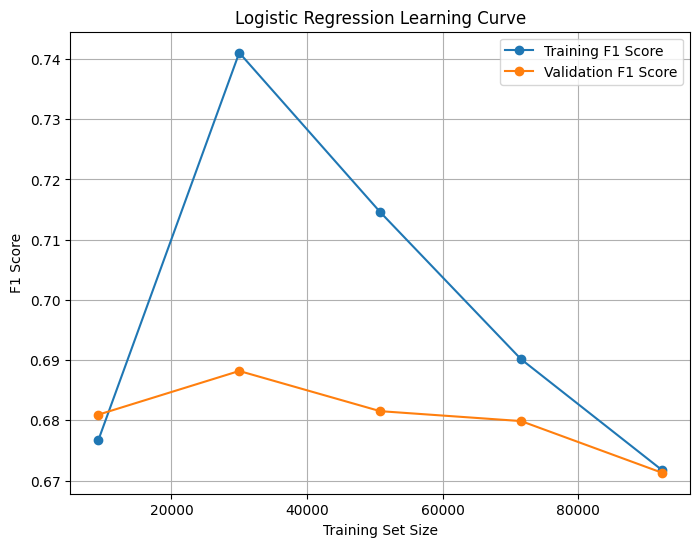

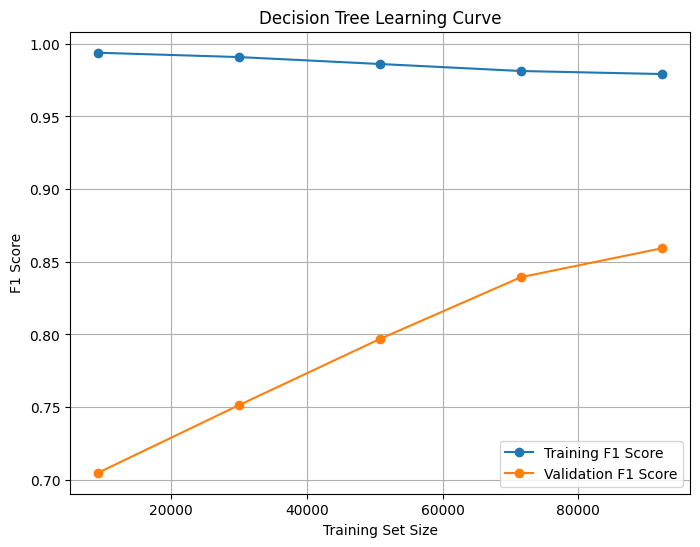

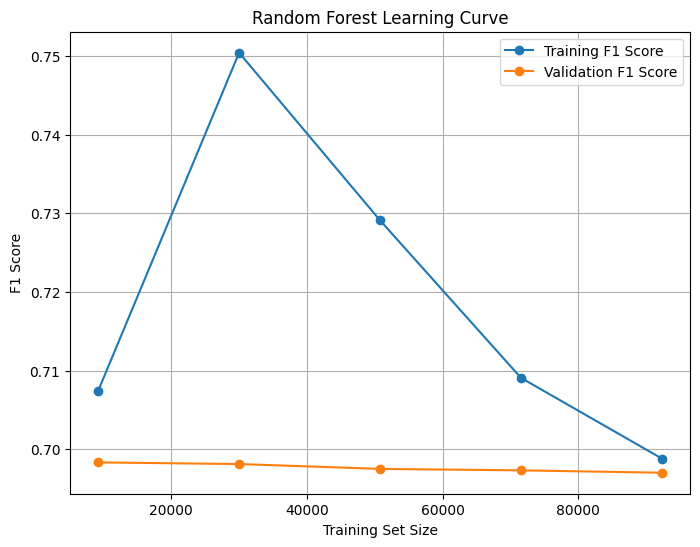

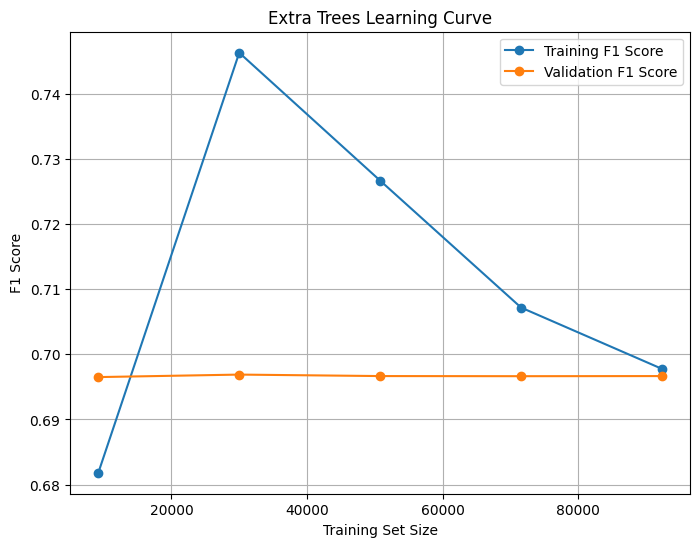

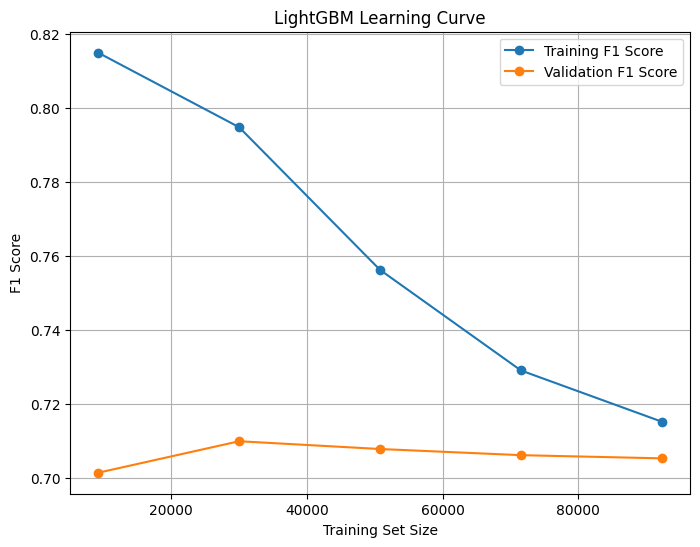

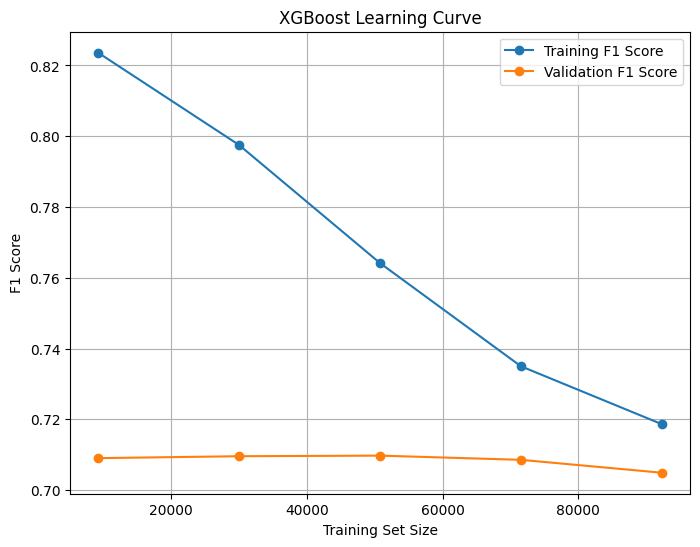

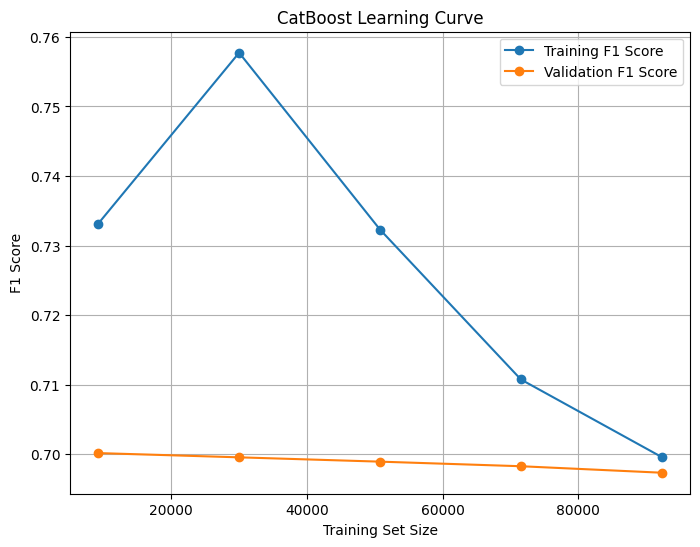

In [13]:
# Plot Learning Curves
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, valid_scores = learning_curve(
        estimator, X, y, cv=5, scoring='f1', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
    )

    train_scores_mean = np.mean(train_scores, axis=1)
    valid_scores_mean = np.mean(valid_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_scores_mean, label='Training F1 Score', marker='o')
    plt.plot(train_sizes, valid_scores_mean, label='Validation F1 Score', marker='o')
    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid()
    plt.show()

plot_learning_curve(logit, X_train_selected, y_train, 'Logistic Regression Learning Curve')
plot_learning_curve(dt, X_train_selected, y_train, 'Decision Tree Learning Curve')
plot_learning_curve(rf, X_train_selected, y_train, 'Random Forest Learning Curve')
plot_learning_curve(extra_trees, X_train_selected, y_train, 'Extra Trees Learning Curve')
plot_learning_curve(lgbm, X_train_selected, y_train, 'LightGBM Learning Curve')
plot_learning_curve(xgb, X_train_selected, y_train, 'XGBoost Learning Curve')
plot_learning_curve(catboost, X_train_selected, y_train, 'CatBoost Learning Curve')

In [ ]:
dgsg 
# Buka UI
mlflow ui `
  --backend-store-uri "sqlite:///D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/mlflow/mlflow.db" `
  --default-artifact-root "file:///D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/mlflow/artifacts" `
  --host 127.0.0.1 `
  --port 5000
conda activate py311_env

NameError: name 'dgsg' is not defined

### Model Tuning

In [ ]:
import optuna
from xgboost import XGBClassifier

def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "booster": "gbtree",

        # narrowed dari hasil trial terbaik
        "n_estimators": trial.suggest_int("n_estimators", 1800, 3200),
        "learning_rate": trial.suggest_float("learning_rate", 0.0045, 0.012, log=True),
        "max_depth": trial.suggest_int("max_depth", 6, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 0.05, 0.8, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 0.8),

        "subsample": trial.suggest_float("subsample", 0.92, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.86, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.72, 0.86),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.68, 0.80),

        "reg_alpha": trial.suggest_float("reg_alpha", 1e-9, 1e-5, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.05, 3.0, log=True),
        "max_bin": trial.suggest_int("max_bin", 180, 220),

        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist",
    }

    # log kamu nunjuk threshold rendah sering bikin score anjlok
    threshold = trial.suggest_float("threshold", 0.455, 0.500)

    model = XGBClassifier(**params)

    model.fit(
        X_train_selected,
        y_train,
        eval_set=[(X_valid_selected, y_valid)],
        verbose=False
    )

    y_proba = model.predict_proba(X_valid_selected)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    recall_0 = recall_score(y_valid, y_pred, pos_label=0, zero_division=0)
    recall_1 = recall_score(y_valid, y_pred, pos_label=1, zero_division=0)

    precision_1 = precision_score(y_valid, y_pred, pos_label=1, zero_division=0)
    f1_0 = f1_score(y_valid, y_pred, pos_label=0, zero_division=0)
    f1_1 = f1_score(y_valid, y_pred, pos_label=1, zero_division=0)

    # balanced recall, tapi kelas 1 sedikit lebih penting
    score = (0.47 * recall_0) + (0.53 * recall_1)

    # penalti kalau timpang
    score -= abs(recall_1 - recall_0) * 0.25

    # batas minimal, sesuaikan dengan targetmu
    min_recall_0 = 0.68
    min_recall_1 = 0.72

    if recall_0 < min_recall_0:
        score -= (min_recall_0 - recall_0) * 3.0

    if recall_1 < min_recall_1:
        score -= (min_recall_1 - recall_1) * 2.5

    trial.set_user_attr("recall_0", recall_0)
    trial.set_user_attr("recall_1", recall_1)
    trial.set_user_attr("precision_1", precision_1)
    trial.set_user_attr("f1_0", f1_0)
    trial.set_user_attr("f1_1", f1_1)
    trial.set_user_attr("threshold", threshold)
    trial.set_user_attr("score", score)

    return score

In [16]:
mlflow.set_experiment(experiment_id=EXPERIMENT_TUNING_ID)

study = optuna.create_study(
    direction="maximize",
    study_name="xgboost_late_shipment_tuning"
)

study.optimize(
    objective,
    n_trials=300,
    timeout=60 * 60,
    show_progress_bar=True
)

print("Best score:", study.best_value)
print("Best params:", study.best_params)
print("Best f1_0:", study.best_trial.user_attrs["f1_0"])
print("Best f1_1:", study.best_trial.user_attrs["f1_1"])
print("Best threshold:", study.best_trial.user_attrs["threshold"])

[I 2026-05-12 12:21:16,254] A new study created in memory with name: xgboost_late_shipment_tuning


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-05-12 12:21:20,599] Trial 0 finished with value: 0.619585681577014 and parameters: {'booster': 'gbtree', 'n_estimators': 1351, 'learning_rate': 0.19187043440111334, 'max_depth': 7, 'min_child_weight': 4.862506151017946, 'gamma': 8.753447620852825, 'subsample': 0.5970053114595928, 'colsample_bytree': 0.5539365677621206, 'colsample_bylevel': 0.8913876580998852, 'colsample_bynode': 0.9356195432260385, 'reg_alpha': 0.02525167662886404, 'reg_lambda': 0.00010219176048880504, 'max_bin': 190, 'threshold': 0.4926145861104334}. Best is trial 0 with value: 0.619585681577014.
[I 2026-05-12 12:21:27,405] Trial 1 finished with value: 0.6195020639739877 and parameters: {'booster': 'gbtree', 'n_estimators': 2073, 'learning_rate': 0.021250528215560404, 'max_depth': 6, 'min_child_weight': 0.0001837973513362628, 'gamma': 5.945461512375942, 'subsample': 0.5850301071305211, 'colsample_bytree': 0.9487455123437099, 'colsample_bylevel': 0.6040065810253349, 'colsample_bynode': 0.9836310692198299, 'reg_

In [18]:
from pathlib import Path
import json
import mlflow
import mlflow.xgboost

from xgboost import XGBClassifier

if mlflow.active_run() is not None:
    mlflow.end_run()

PROJECT_ROOT = Path(
    r"D:\PENS-EEPIS\SDT A Semester 4 2026\Project TA"
)

MLFLOW_DIR = PROJECT_ROOT / "model" / "artifacts" / "mlflow"
TRACKING_DB = MLFLOW_DIR / "mlflow.db"
ARTIFACT_DIR = MLFLOW_DIR / "artifacts"
METRICS_DIR = PROJECT_ROOT / "model" / "artifacts" / "metrics" / "mlflow_artifacts"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{TRACKING_DB.as_posix()}")

MLFLOW_EXPERIMENT_TUNING = "late-shipment-risk-model-tuning"
REGISTERED_MODEL_NAME = "Late Shipment Risk Model"

mlflow.set_experiment(experiment_id=EXPERIMENT_TUNING_ID)

best_params = study.best_params.copy()
best_threshold = best_params.pop("threshold")

final_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
    "tree_method": "hist",
    **best_params
}

best_summary = {
    "best_score": study.best_value,
    "best_threshold": best_threshold,
    "best_f1_0": study.best_trial.user_attrs["f1_0"],
    "best_f1_1": study.best_trial.user_attrs["f1_1"],
    "best_params_for_model": final_params,
    "best_params_from_optuna": study.best_params,
}

best_xgb = XGBClassifier(**final_params)

with mlflow.start_run(run_name="XGBoost_Optuna_Best") as run:
    tuning_run_id = run.info.run_id

    mlflow.set_tag("model_name", "XGBoost")
    mlflow.set_tag("stage", "model_tuning")
    mlflow.set_tag("tuning_method", "Optuna")
    mlflow.set_tag("target", "Late_delivery_risk")

    mlflow.log_params(final_params)
    mlflow.log_param("best_threshold", best_threshold)
    mlflow.log_metric("best_score", study.best_value)
    mlflow.log_param("imbalance_mode", "none")
    mlflow.log_param("n_trials", len(study.trials))
    mlflow.log_param("train_rows", X_train_selected.shape[0])
    mlflow.log_param("valid_rows", X_valid_selected.shape[0])
    mlflow.log_param("n_features", X_train_selected.shape[1])

    best_xgb.fit(
        X_train_selected,
        y_train,
        eval_set=[(X_valid_selected, y_valid)],
        verbose=False
    )

    y_proba_xgb_tuned = best_xgb.predict_proba(X_valid_selected)[:, 1]
    y_pred_xgb_tuned = (y_proba_xgb_tuned >= best_threshold).astype(int)

    tuned_metrics = {
        "accuracy": accuracy_score(y_valid, y_pred_xgb_tuned),
        "precision_0": precision_score(y_valid, y_pred_xgb_tuned, pos_label=0, zero_division=0),
        "recall_0": recall_score(y_valid, y_pred_xgb_tuned, pos_label=0, zero_division=0),
        "f1_0": f1_score(y_valid, y_pred_xgb_tuned, pos_label=0, zero_division=0),
        "precision_1": precision_score(y_valid, y_pred_xgb_tuned, pos_label=1, zero_division=0),
        "recall_1": recall_score(y_valid, y_pred_xgb_tuned, pos_label=1, zero_division=0),
        "f1_1": f1_score(y_valid, y_pred_xgb_tuned, pos_label=1, zero_division=0),
        "macro_f1": f1_score(y_valid, y_pred_xgb_tuned, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_valid, y_pred_xgb_tuned, average="weighted", zero_division=0),
        "roc_auc": roc_auc_score(y_valid, y_proba_xgb_tuned),
    }

    mlflow.log_metrics(tuned_metrics)

    xgb_tuned_report = classification_report(y_valid, y_pred_xgb_tuned, zero_division=0)
    xgb_tuned_cm = confusion_matrix(y_valid, y_pred_xgb_tuned)

    report_path = METRICS_DIR / "xgb_optuna_classification_report.txt"
    cm_path = METRICS_DIR / "xgb_optuna_confusion_matrix.txt"
    params_path = METRICS_DIR / "xgb_optuna_best_params.json"

    report_path.write_text(xgb_tuned_report, encoding="utf-8")
    cm_path.write_text(str(xgb_tuned_cm), encoding="utf-8")
    params_path.write_text(json.dumps(best_summary, indent=4), encoding="utf-8")

    mlflow.log_artifact(str(report_path))
    mlflow.log_artifact(str(cm_path))
    mlflow.log_artifact(str(params_path))

    logged_model = mlflow.xgboost.log_model(
    xgb_model=best_xgb,
    name="xgboost_optuna_model"
    )
    
    tuned_model_uri = logged_model.model_uri


print("Tuning run ID:", tuning_run_id)
print("Tracking URI:", mlflow.get_tracking_uri())
print("Best score:", study.best_value)
print("Best threshold:", best_threshold)
print("Best params for model:")
print(final_params)

Tuning run ID: 60c3f9a1cf934db3898d0d8552c83fec
Tracking URI: sqlite:///D:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/mlflow/mlflow.db
Best score: 0.6287991987737989
Best threshold: 0.47624850862608875
Best params for model:
{'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'booster': 'gbtree', 'n_estimators': 2959, 'learning_rate': 0.006547542139819048, 'max_depth': 8, 'min_child_weight': 0.0552195765665314, 'gamma': 0.32190894862040537, 'subsample': 0.5181172011287464, 'colsample_bytree': 0.9641553847155946, 'colsample_bylevel': 0.7821466165369408, 'colsample_bynode': 0.8609326137598762, 'reg_alpha': 1.6805206087884637e-07, 'reg_lambda': 3.86216071524924, 'max_bin': 206}


In [19]:
print("XGBoost Optuna Evaluation")
print("Best threshold:", best_threshold)
print("Best params:", final_params)
print("\nClassification Report:")
print(xgb_tuned_report)
print("\nConfusion Matrix:")
print(xgb_tuned_cm)
print("\nMetrics:")
print(tuned_metrics)

XGBoost Optuna Evaluation
Best threshold: 0.47624850862608875
Best params: {'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'booster': 'gbtree', 'n_estimators': 2959, 'learning_rate': 0.006547542139819048, 'max_depth': 8, 'min_child_weight': 0.0552195765665314, 'gamma': 0.32190894862040537, 'subsample': 0.5181172011287464, 'colsample_bytree': 0.9641553847155946, 'colsample_bylevel': 0.7821466165369408, 'colsample_bynode': 0.8609326137598762, 'reg_alpha': 1.6805206087884637e-07, 'reg_lambda': 3.86216071524924, 'max_bin': 206}

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.78      0.71     13050
           1       0.78      0.64      0.70     15777

    accuracy                           0.70     28827
   macro avg       0.71      0.71      0.70     28827
weighted avg       0.72      0.70      0.70     28827


Confusion Matrix:
[[10230  2820]
 [ 5707 10070]]



In [20]:
from mlflow import MlflowClient

client = MlflowClient()

model_uri = tuned_model_uri

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=REGISTERED_MODEL_NAME
)

client.set_registered_model_alias(
    name=REGISTERED_MODEL_NAME,
    alias="champion",
    version=registered_model.version
)

print("Registered model:", REGISTERED_MODEL_NAME)
print("Version:", registered_model.version)
print("Alias: champion")

Registered model: Late Shipment Risk Model
Version: 1
Alias: champion


Successfully registered model 'Late Shipment Risk Model'.
Created version '1' of model 'Late Shipment Risk Model'.


# Comparison Model Terbaik

In [21]:
import mlflow
import mlflow.lightgbm
from mlflow import MlflowClient

mlflow.set_tracking_uri(f"sqlite:///{TRACKING_DB.as_posix()}")

model_name = REGISTERED_MODEL_NAME
model_alias = "champion"

client = MlflowClient()

champion_info = client.get_model_version_by_alias(
    name=model_name,
    alias=model_alias
)

print("Model name :", model_name)
print("Alias      :", model_alias)
print("Version    :", champion_info.version)
print("Run ID     :", champion_info.run_id)
print("Source     :", champion_info.source)

model_uri = f"models:/{model_name}@{model_alias}"

champion_model = mlflow.xgboost.load_model(model_uri)

run = client.get_run(champion_info.run_id)

best_threshold = float(
    run.data.params.get("best_threshold", 0.5)
)

print("Best threshold:", best_threshold)

Model name : Late Shipment Risk Model
Alias      : champion
Version    : 1
Run ID     : 60c3f9a1cf934db3898d0d8552c83fec
Source     : models:/m-255a6e54375141acb5f21439d8843f6d
Best threshold: 0.47624850862608875


In [22]:
y_proba_champion = champion_model.predict_proba(X_test_selected)[:, 1]
y_pred_champion = (y_proba_champion >= best_threshold).astype(int)

print(y_pred_champion[:10])
print(y_proba_champion[:10])

[0 0 1 1 1 1 1 1 0 1]
[0.21649122 0.37859342 0.80184263 0.7218339  0.99457717 0.7525076
 0.97882473 0.9847601  0.40812716 0.8609964 ]


In [23]:
# bandingkan hasil prediksi dengan label asli
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_proba_champion = champion_model.predict_proba(X_test_selected)[:, 1]
y_pred_champion = (y_proba_champion >= best_threshold).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_champion, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_champion))

print("Accuracy :", accuracy_score(y_test, y_pred_champion))
print("Precision:", precision_score(y_test, y_pred_champion, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_champion, zero_division=0))
print("F1 Score :", f1_score(y_test, y_pred_champion, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_champion))


Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.77      0.70     16200
           1       0.77      0.63      0.69     19669

    accuracy                           0.70     35869
   macro avg       0.70      0.70      0.70     35869
weighted avg       0.71      0.70      0.70     35869

Confusion Matrix:
[[12548  3652]
 [ 7281 12388]]
Accuracy : 0.6951964091555382
Precision: 0.7723192019950125
Recall   : 0.6298235802531903
F1 Score : 0.6938306869416674
ROC AUC  : 0.7560276527141475


# Outputkan Model ke Artifacts

In [24]:
import os
import json
import joblib

artifact_dir = "d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/models/champion_model"
os.makedirs(artifact_dir, exist_ok=True)

model_pkl_path = os.path.join(artifact_dir, "late_shipment_model.pkl")
metadata_path = os.path.join(artifact_dir, "metadata.json")

joblib.dump(champion_model, model_pkl_path)

metadata = {
    "model_name": model_name,
    "alias": model_alias,
    "version": champion_info.version,
    "run_id": champion_info.run_id,
    "threshold": best_threshold,
    "features": list(X_test_selected.columns),
    "target": "Late_delivery_risk"
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4)

print("Model saved to:", model_pkl_path)
print("Metadata saved to:", metadata_path)

Model saved to: d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/models/champion_model\late_shipment_model.pkl
Metadata saved to: d:/PENS-EEPIS/SDT A Semester 4 2026/Project TA/model/artifacts/models/champion_model\metadata.json
